In [298]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

#### Correzzioni degli offset.


Nella correzione Lente 1, offset_LENTE1_A e offset_LENTE1_B rappresentano rispettivamente la distanza tra l'asse del carrellino e V e la distanza tra l asse del carrellino e V'.

VV_LENTE1 è la distanza VV' data come specifica della lente (c'è una piccola incongruenza dato che la somma di offset_A e offset_B non è uguale a VV).

In offset_LENTE1_q e offset_LENTE1_p il primo e secondo termine se sommati definiscono l'offset dell'asse della lente (che non combacia con l'asse del carrellino) mentre VV/3 rappresenta l'offset dovuto alla distanza tra asse della lente e i piani principali.

In offset_LENTE2 avremmo dovuto applicare lo stesso concetto ma, non avendo a disposizione una misura paragonabile a offset_A e offset_B ma per la lente 2, si preferisce approssimare il centro della lente come coincidente al centro del carrellino.

In [299]:
tecnica = 0.3 * 1/np.sqrt(12)

In [300]:
#Correzione distanza oggetto:
SBARRETTA = [82.0, 0.5/np.sqrt(24)]
SCHERMO = [75.0, tecnica]
CARRELLINO = [25.4, tecnica]
OGGETTO = [35.0, 0.5/np.sqrt(24)]
offset_OGGETTO = [SBARRETTA[0] + SCHERMO[0]/2 - CARRELLINO[0]/2 - OGGETTO[0],
                  f.propaga_incertezza(
                        "x + y - z/2 - w",
                        ["x","y","z","w"],
                        [SBARRETTA[0],SCHERMO[0],CARRELLINO[0],OGGETTO[0]],
                        [SBARRETTA[1],SCHERMO[1],CARRELLINO[1],OGGETTO[1]],
                        ritorno=True
                  )[0]
                  ]

print(f"offset_OGGETTO = {gf.formatta_errore(offset_OGGETTO[0],offset_OGGETTO[1],txt=True)}")

#Correzione CCD:
PIANO_IMMAGINE = [9.0, tecnica]
CCD = [6.0, tecnica]
offset_CCD = [CARRELLINO[0]/2 + PIANO_IMMAGINE[0] - CCD[0],
                f.propaga_incertezza(
                        "x/2 + y - z",
                        ["x","y","z"],
                        [CARRELLINO[0],PIANO_IMMAGINE[0],CCD[0]],
                        [CARRELLINO[1],PIANO_IMMAGINE[1],CCD[1]],
                        ritorno=True
                )[0]
                ]

print(f"offset_CCD = {gf.formatta_errore(offset_CCD[0],offset_CCD[1],txt=True)}")

#Correzione Lente 1:
PA = [69.0, 0.5/np.sqrt(24)]
PB = [77.0, 0.5/np.sqrt(24)]
LENTE1 = [170.5, 0.5/np.sqrt(24)]
offset_LENTE1_A = [CARRELLINO[0] + LENTE1[0] - PA[0] - SCHERMO[0]/2 - SBARRETTA[0],
                   f.propaga_incertezza(
                       "x + y - z - w/2 - q",
                       ["x","y","z","w","q"],
                       [CARRELLINO[0],LENTE1[0],PA[0],SCHERMO[0],SBARRETTA[0]],
                       [CARRELLINO[1],LENTE1[1],PA[1],SCHERMO[1],SBARRETTA[1]],
                       ritorno=True
                   )[0]
                   ]

print(f"offset_LENTE1_A = {gf.formatta_errore(offset_LENTE1_A[0],offset_LENTE1_A[1],txt=True)}")

offset_LENTE1_B = [CARRELLINO[0] + LENTE1[0] - PB[0] - SCHERMO[0]/2 - SBARRETTA[0],
                   f.propaga_incertezza(
                       "x + y - z - w/2 - q",
                       ["x","y","z","w","q"],
                       [CARRELLINO[0],LENTE1[0],PB[0],SCHERMO[0],SBARRETTA[0]],
                       [CARRELLINO[1],LENTE1[1],PB[1],SCHERMO[1],SBARRETTA[1]],
                       ritorno=True
                   )[0]
                   ]

print(f"offset_LENTE1_B = {gf.formatta_errore(offset_LENTE1_B[0],offset_LENTE1_B[1],txt=True)}")

VV_LENTE1 = [offset_LENTE1_A[0] + offset_LENTE1_B[0],
                   f.propaga_incertezza(
                       "x + y",
                       ["x","y"],
                       [offset_LENTE1_A[0],offset_LENTE1_B[0]],
                       [offset_LENTE1_A[1],offset_LENTE1_B[1]],
                       ritorno=True
                   )[0]
                   ]

print(f"VV_LENTE1 = {gf.formatta_errore(VV_LENTE1[0],VV_LENTE1[1],txt=True)}")

VV_LENTE1_real = [7.2, 0.1]

print(f"VV_LENTE1_real = {gf.formatta_errore(VV_LENTE1_real[0],VV_LENTE1_real[1],txt=True)}")
print(f"Indice di compatibilità tra i due valori di VV' = {f.compatibilita(VV_LENTE1[0], VV_LENTE1[1], VV_LENTE1_real[0], VV_LENTE1_real[1])}")

offset_LENTE1_p = [CARRELLINO[0]/2 - (offset_LENTE1_A[0] - offset_LENTE1_B[0])/2 - (VV_LENTE1_real[0]/3)/2,
                   f.propaga_incertezza(
                       "x/2 - (y - z)/2 - w/6",
                       ["x","y","z","w"],
                       [CARRELLINO[0], offset_LENTE1_A[0], offset_LENTE1_B[0], VV_LENTE1_real[0]],
                       [CARRELLINO[1], offset_LENTE1_A[1], offset_LENTE1_B[1], VV_LENTE1_real[1]],
                       ritorno=True
                   )[0]
                ]

print(f"offset_LENTE1_p = {gf.formatta_errore(offset_LENTE1_p[0],offset_LENTE1_p[1],txt=True)}")

offset_LENTE1_q = [CARRELLINO[0]/2 - (offset_LENTE1_A[0] - offset_LENTE1_B[0])/2 + (VV_LENTE1_real[0]/3)/2,
                   f.propaga_incertezza(
                       "x/2 - (y - z)/2 + w/6",
                       ["x","y","z","w"],
                       [CARRELLINO[0], offset_LENTE1_A[0], offset_LENTE1_B[0], VV_LENTE1_real[0]],
                       [CARRELLINO[1], offset_LENTE1_A[1], offset_LENTE1_B[1], VV_LENTE1_real[1]],
                       ritorno=True
                   )[0]
                ]

print(f"offset_LENTE1_q = {gf.formatta_errore(offset_LENTE1_q[0],offset_LENTE1_q[1],txt=True)}")


"""
Correzione Lente 2:
offset_LENTE2_A = 0
offset_LENTE2_B = 0
VV_LENTE2 = 10.1
offset_LENTE1_p = 25.4/2 - (offset_LENTE1_A - offset_LENTE1_B)/2 - (VV_LENTE1/3)/2
offset_LENTE1_q = 25.4/2 - (offset_LENTE1_A - offset_LENTE1_B)/2 + (VV_LENTE1/3)/2
"""

#Correzione dei dati del secondo giorno (in realtà terzo) per la rotazione della mascherina
offset_GIORNO2 = - 7
#Lunghezza totale (per Bessel)
lunghezza = [561.0, 0.5/np.sqrt(24)]

offset_OGGETTO = 71.8 ± 0.2 
offset_CCD = 15.7 ± 0.1 
offset_LENTE1_A = 7.4 ± 0.2 
offset_LENTE1_B = -0.6 ± 0.2 
VV_LENTE1 = 6.8 ± 0.3 
VV_LENTE1_real = 7.2 ± 0.1 
Indice di compatibilità tra i due valori di VV' = 1.3241694217637514
offset_LENTE1_p = 7.5 ± 0.1 
offset_LENTE1_q = 9.9 ± 0.1 


Il valore "-7" è assunto senza errore, dato dalla Sada.

Viene stimata la compatibilità tra VV' e la somma tra offset_A e offset_B.

Le misure date nelle specifiche tecniche quali CARRELLINO o simili hanno incertezza data da la risoluzione in pollici convertita in mm poi divisa per radice di 12 (considerando quindi una distribuzione uniforme).

In [301]:
file_focali = "focali.txt"
file_aberrazione = "aberrazione.txt"

# 1. Punti Coniugati


In [302]:
metodo = "Coniugati"

### 1.1 Lettura

In [303]:
def nome (stringa, cartella):
    """
    Estrae il nome dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace(f'./Data/{cartella}/dati_','').replace('.csv','')
    return stringa_nuova

In [304]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data1 = {}

for input_file in input_files:
    letti = pd.read_csv(input_file)

    data1[nome(input_file, metodo)] = {
        "immagine": np.array(letti["immagine"], dtype=float),
        "lente": np.array(letti["lente"], dtype=float),
    }

### 1.2 Analisi

$$
Y = \frac{1}{f} - X
$$

$$
\frac{1}{x_{lente}} = \frac{1}{f} - \frac{1}{x_{immagine}}
$$

Le incertezze usate sono state stimate come risoluzione (0.5mm) fratto il quadrato della misura: questo è dovuto alla propagazione delle incertezze per il reciproco di un valore.

##### Fit con ODR lineare e non lineare.

In [305]:
distanze = {} # Contiene i campioni p e q con relative incertezze
focali1 = {} # Contiene le migliori stime delle focali con punti coniugati
focali_comp = {} # Contiene tutte le stime delle focali, usato per compatibilità tra i vari metodi
focali_anal = {} # Contiene i parametri del fit lineare per verificarne la bontà

p_err = np.sqrt( (0.5/np.sqrt(24))**2 + offset_OGGETTO[1]**2 + offset_LENTE1_p[1]**2 )
q_err = np.sqrt( (0.5/np.sqrt(24))**2 + (0.5/np.sqrt(24))**2 + offset_OGGETTO[1]**2 + offset_LENTE1_p[1]**2 + offset_LENTE1_q[1]**2 + offset_CCD[1]**2 )

for i, (colore, dati) in enumerate(data1.items()):
    # Aggiunta offset
    if colore == "rosso":
        p = dati["lente"] + offset_OGGETTO[0] + offset_GIORNO2 + offset_LENTE1_p[0]
    else:
        p = dati["lente"] + offset_OGGETTO[0] + offset_LENTE1_p[0]
    q = dati["immagine"] - (dati["lente"] + offset_LENTE1_q[0]) + offset_CCD[0]
    p = [p,p_err]
    q = [q,q_err]
    distanze[colore] = {"p": p, "q": q}

    # Fit linearizzato ODR
    anal = f.elaborato(1/q[0], 1/p[0], q[1] / (q[0]**2), p[1] / (p[0]**2), None, i, elaborato=False)
    f_l = [1/anal[0], anal[2]/anal[0]**2]
    focali_anal[colore] = {"a" : [anal[0],anal[2]],
                           "b" : [anal[1],anal[3]],
                           "cov" : anal[4]}

    # Fit non linearizzato ODR
    from scipy.odr import ODR, Model, RealData
    def modello(B, x):
        return (B*x) / (x - B)
    data = RealData(p[0], q[0], sx=p[1], sy=q[1])
    model = Model(modello)
    odr = ODR(data, model, beta0=[10])
    output = odr.run()
    f_nl = [output.beta[0],output.sd_beta[0]]
    focali_comp[colore] = {"lineare" : f_nl,
                           "non_lineare" : f_l}

    print(f"Fit {colore}")
    print(f"\tf stima lineare ODR: {gf.formatta_errore(f_l[0],f_l[1],txt=True)}")
    print(f"\tf stima non lineare ODR: {gf.formatta_errore(f_nl[0],f_nl[1],txt=True)}\n")

Fit ambra
	f stima lineare ODR: 150.7 ± 0.8 
	f stima non lineare ODR: 149.5 ± 0.2 

Fit blu
	f stima lineare ODR: 144 ± 2 
	f stima non lineare ODR: 147.8 ± 0.1 

Fit rosso
	f stima lineare ODR: 150.3 ± 0.3 
	f stima non lineare ODR: 150.76 ± 0.02 



Valutazione fit lineare: compatibilità pendenza e differenza intercette con modello teorico

Per quanto riguarda la differenza tra le intercette su asse x e asse y (che dovrebbe risultare compatibile con zero) viene usata la seguente formula.

$$
x_0 - y_0 = -mq - q = q(-m - 1)
$$

In [306]:
for colore,focale_anal in focali_anal.items():
    a = focale_anal["a"]
    b = focale_anal["b"]
    cov = focale_anal["cov"]
    diff = [a[0] * (-b[0] - 1),
            (((b[0] + 1)**2) * a[1]**2 + (a[0]**2) * b[1]**2 + 2 * a[0] * (b[0] + 1) * cov) ** 0.5]

    print(f"Colore: {colore}")
    print(f"\tPendenza: {gf.formatta_errore(b[0], b[1], txt=True)}")
    print(f"\tCompatibilità pendenza vs teorica (-1): {f.compatibilita(b[0], b[1], -1, 0)}")
    print(f"\tDifferenza intercette: {gf.formatta_errore(diff[0], diff[1], txt=True)}")
    print(f"\tCompatibilità differenza intercette vs teorica (0): {f.compatibilita(diff[0], diff[1], 0, 0)}\n")
    del diff

Colore: ambra
	Pendenza: -0.99 ± 0.01 
	Compatibilità pendenza vs teorica (-1): 1.3696951988791617
	Differenza intercette: -0.00009 ± 0.00007 
	Compatibilità differenza intercette vs teorica (0): 1.3699965891274237

Colore: blu
	Pendenza: -1.04 ± 0.02 
	Compatibilità pendenza vs teorica (-1): 1.5790302466877197
	Differenza intercette: 0.0003 ± 0.0002 
	Compatibilità differenza intercette vs teorica (0): 1.5741489811848564

Colore: rosso
	Pendenza: -1.005 ± 0.004 
	Compatibilità pendenza vs teorica (-1): 1.3432080141928202
	Differenza intercette: 0.00003 ± 0.00003 
	Compatibilità differenza intercette vs teorica (0): 1.3367426648996956



##### Minimizzazione quadrati metrica chi-quadro non pesato.

$$ f = A $$
$$ S_A = \sum_i \left( q_i - \frac{p_i A}{\,p_i - A\,} \right)^2 $$
$$ f^{-1} = B $$
$$ S_B = \sum_i \left( q_i - \frac{p_i}{\,p_i B - 1\,} \right)^2 $$

In [309]:
from scipy.optimize import minimize
for colore, distanza in distanze.items():
    # A
    def chi2(A, x, y):
        return np.sum((y - (A * x) / (x - A))**2)
    p = distanza["p"]
    q = distanza["q"]
    res = minimize(chi2, 
                   focali_comp[colore]["lineare"][0],
                   args=(p[0], q[0]))
    anal = [res.x[0], np.sqrt(abs(res.hess_inv[0][0]))]
    print(f"Fit {colore}, calcolo di A")
    print(f"\tf = {gf.formatta_errore(anal[0],anal[1],txt=True)}")

    # Calcolo semidispersione
    A_vals = np.linspace(f.percento(res.x[0],20,"-"), f.percento(res.x[0],20,"+"), 500)
    SA_vals = np.array([chi2(A0,p[0],q[0]) for A0 in A_vals])
    min_index = np.argmin(SA_vals)
    SA_min = SA_vals[min_index]
    A_min = A_vals[min_index]
    indices = np.where(SA_vals >= SA_min + 1)[0]
    left_index = indices[indices < min_index][-1]
    right_index = indices[indices > min_index][0]
    A_left = A_vals[left_index]
    A_right = A_vals[right_index]
    semidispersione = (A_right - A_left) / 2
    print(f"\tSemidispersione = {semidispersione}")
    focali_comp[colore]["minimi_quadrati"] = [anal[0],semidispersione]

    # B
    def chi2(B, x, y):
        return np.sum((y - (x) / (B * x - 1))**2)
    res = minimize(chi2, 
                   1/focali_comp[colore]["lineare"][0],
                   args=(p[0], q[0]))
    anal = [res.x[0], np.sqrt(abs(res.hess_inv[0][0]))]
    print(f"Fit {colore}, calcolo di B")
    print(f"\tf = {gf.formatta_errore(1/anal[0],anal[1]/anal[0]**2,txt=True)}")

    # Calcolo semidispersione
    A_vals = np.linspace(f.percento(res.x[0],20,"-"), f.percento(res.x[0],20,"+"), 500)
    SA_vals = np.array([chi2(A0,p[0],q[0]) for A0 in A_vals])
    min_index = np.argmin(SA_vals)
    SA_min = SA_vals[min_index]
    A_min = A_vals[min_index]
    indices = np.where(SA_vals >= SA_min + 1)[0]
    left_index = indices[indices < min_index][-1]
    right_index = indices[indices > min_index][0]
    A_left = A_vals[left_index]
    A_right = A_vals[right_index]
    semidispersione = (A_right - A_left) / 2
    print(f"\tSemidispersione = {semidispersione / anal[0]**2}\n")
    #focali_comp[colore]["minimi_quadrati"] = [anal[0],semidispersione / anal[0]**2]

Fit ambra, calcolo di A
	f = 149.76 ± 0.03 
	Semidispersione = 0.18007223701631858
Fit ambra, calcolo di B
	f = 149.76 ± 0.04 
	Semidispersione = 0.1800724362552704

Fit blu, calcolo di A
	f = 147.80 ± 0.07 
	Semidispersione = 0.17771133645976533
Fit blu, calcolo di B
	f = 147.80 ± 0.07 
	Semidispersione = 0.17771138649766938

Fit rosso, calcolo di A
	f = 150.75 ± 0.05 
	Semidispersione = 0.18126707658191776
Fit rosso, calcolo di B
	f = 150.75 ± 0.05 
	Semidispersione = 0.18126727969971201



##### Stima con campione $f_i$

$$ f_i = \frac{p_i q_i}{p_i + q_i} $$
$$ f_i(s_p) = \frac{(p_i + s_p) q_i}{(p_i + s_p) + q_i} $$
$$ f_i(s_q) = \frac{p_i \,(q_i + s_q)}{p_i + (q_i + s_q)} $$
$$ f_i(s_p, s_q) = \frac{(p_i + s_p)\,(q_i + s_q)}{(p_i + s_p) + (q_i + s_q)} $$

In [315]:
for colore,distanza in distanze.items():
    p = distanza["p"]
    q = distanza["q"]
    f_val = (p[0] * q[0]) / (p[0] + q[0])
    f_p = np.mean( ((p[0] + p[1]) * q[0]) / ((p[0] + p[1]) + q[0]) )
    f_q = np.mean( (p[0] * (q[0] + q[1]) / (p[0] + (q[0] + q[1]))) )
    f_pq = np.mean( ((p[0] + p[1]) * (q[0] + q[1]) / ((p[0] + p[1]) + (q[0] + q[1]))) )
    print(f"Colore : {colore}")
    print(f"\tf_p = {f_p}")
    print(f"\tf_q = {f_q}")
    print(f"\tf_pq = {f_pq}")
    stima = [np.mean(f_val),
             (np.max([f_p,f_q,f_pq]) - np.min([f_p,f_q,f_pq])) / 2]
    print(f"\tStima focale = {gf.formatta_errore(stima[0],stima[1],txt=True)}\n")
    focali_comp[colore]["campione"] = stima

Colore : ambra
	f_p = 149.60086551669403
	f_q = 149.63999309548507
	f_pq = 149.69853309021445
	Stima focale = 149.54 ± 0.05 

Colore : blu
	f_p = 147.8642875348347
	f_q = 147.94545417158687
	f_pq = 147.98572698735686
	Stima focale = 147.82 ± 0.06 

Colore : rosso
	f_p = 150.8148248382203
	f_q = 150.86122334038126
	f_pq = 150.91421159384916
	Stima focale = 150.76 ± 0.05 



##### Valutazione compatibilità tra le varie stime di f.

In [322]:
with open("compatibilita_coniugati.txt", "w") as out:
    for colore, focale in focali_comp.items():
        f_l  = focale["lineare"]
        f_nl = focale["non_lineare"]
        f_ls = focale["minimi_quadrati"]
        f_c  = focale["campione"]

        # Intestazione
        out.write(f"================  {colore.upper()}  ================\n\n")

        # Tabella valori stimati
        out.write("Valori stimati\n")
        out.write("----------------------------------------------\n")
        out.write(f"{'Fit lineare (L)':25} {gf.formatta_errore(f_l[0], f_l[1], txt=True)}\n")
        out.write(f"{'Fit non lineare (NL)':25} {gf.formatta_errore(f_nl[0], f_nl[1], txt=True)}\n")
        out.write(f"{'Fit minimi quadrati (LS)':25} {gf.formatta_errore(f_ls[0], f_ls[1], txt=True)}\n")
        out.write(f"{'Media del campione (C)':25} {gf.formatta_errore(f_c[0], f_c[1], txt=True)}\n\n")

        # Tabella compatibilità
        out.write("Compatibilità\n")
        out.write("----------------------------------------------\n")
        out.write(f"{'L vs NL':25} {f.compatibilita(f_l[0], f_l[1], f_nl[0], f_nl[1])}\n")
        out.write(f"{'L vs LS':25} {f.compatibilita(f_l[0], f_l[1], f_ls[0], f_ls[1])}\n")
        out.write(f"{'NL vs LS':25} {f.compatibilita(f_nl[0], f_nl[1], f_ls[0], f_ls[1])}\n")
        out.write(f"{'C vs L':25} {f.compatibilita(f_c[0], f_c[1], f_l[0], f_l[1])}\n")
        out.write(f"{'C vs NL':25} {f.compatibilita(f_c[0], f_c[1], f_nl[0], f_nl[1])}\n")
        out.write(f"{'C vs LS':25} {f.compatibilita(f_c[0], f_c[1], f_ls[0], f_ls[1])}\n")

        out.write("\n\n")

### 1.3 Grafici

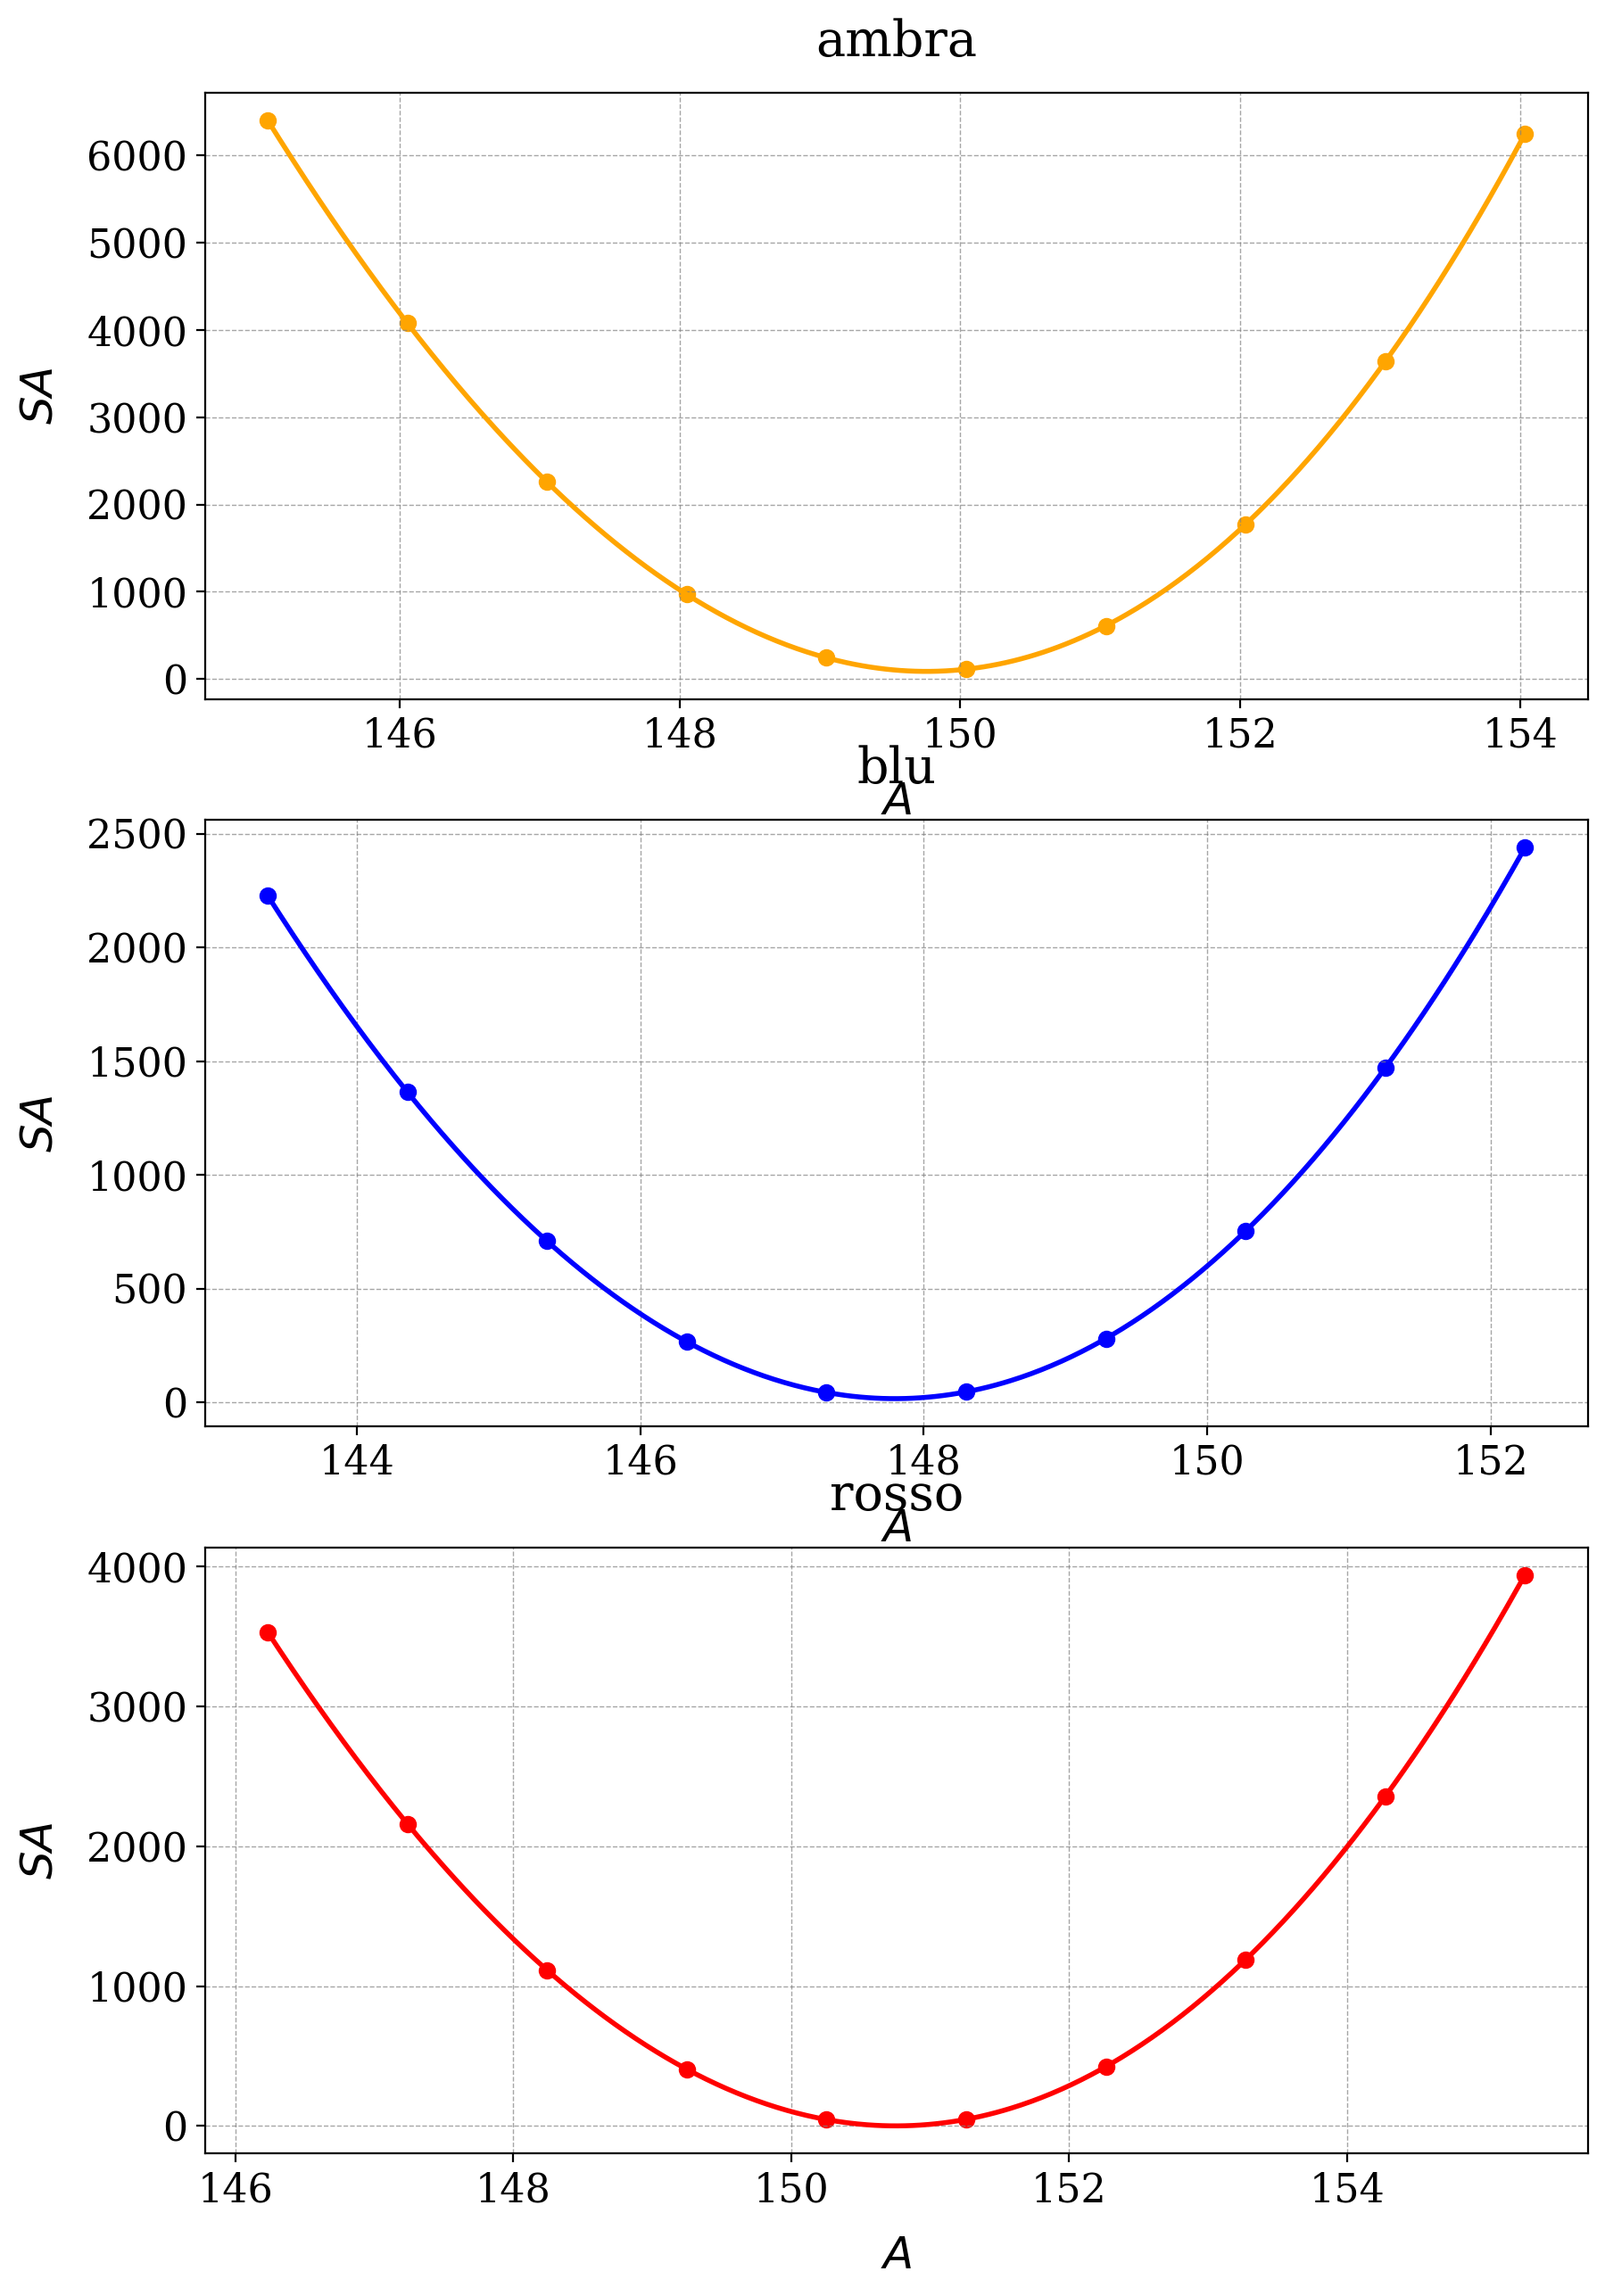

In [ ]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5))
percent_meno = 3
percent_piu = 3

for i, (focale_dict,(colore, distanza)) in enumerate(zip(focali1.values(),distanze.items())):
    ax = axes[i]
    gf.parametri_grafico(ax, colore, "$A$", r"$SA$")
    if i == 0 : colore = "orange"
    elif i == 1 : colore = "blue"
    elif i == 2 : colore = "red"
    focale = np.array([focale_dict["f"],focale_dict["sf"]])
    p = distanza["p"]
    q = distanza["q"]

    A = np.linspace(f.percento(focale[0],percent_meno,"-"), f.percento(focale[0],percent_piu,"+"), 500)
    SA = [np.sum((q[0] - (x_val * p[0]) / (p[0] - x_val))**2) for x_val in A]
    ax.plot(A, SA, color=colore)

    A = np.linspace(f.percento(focale[0],percent_meno,"-"), f.percento(focale[0],percent_piu,"+"), 10)
    SA = [np.sum((q[0] - (x_val * p[0]) / (p[0] - x_val))**2) for x_val in A]
    ax.scatter(A, SA, color=colore)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


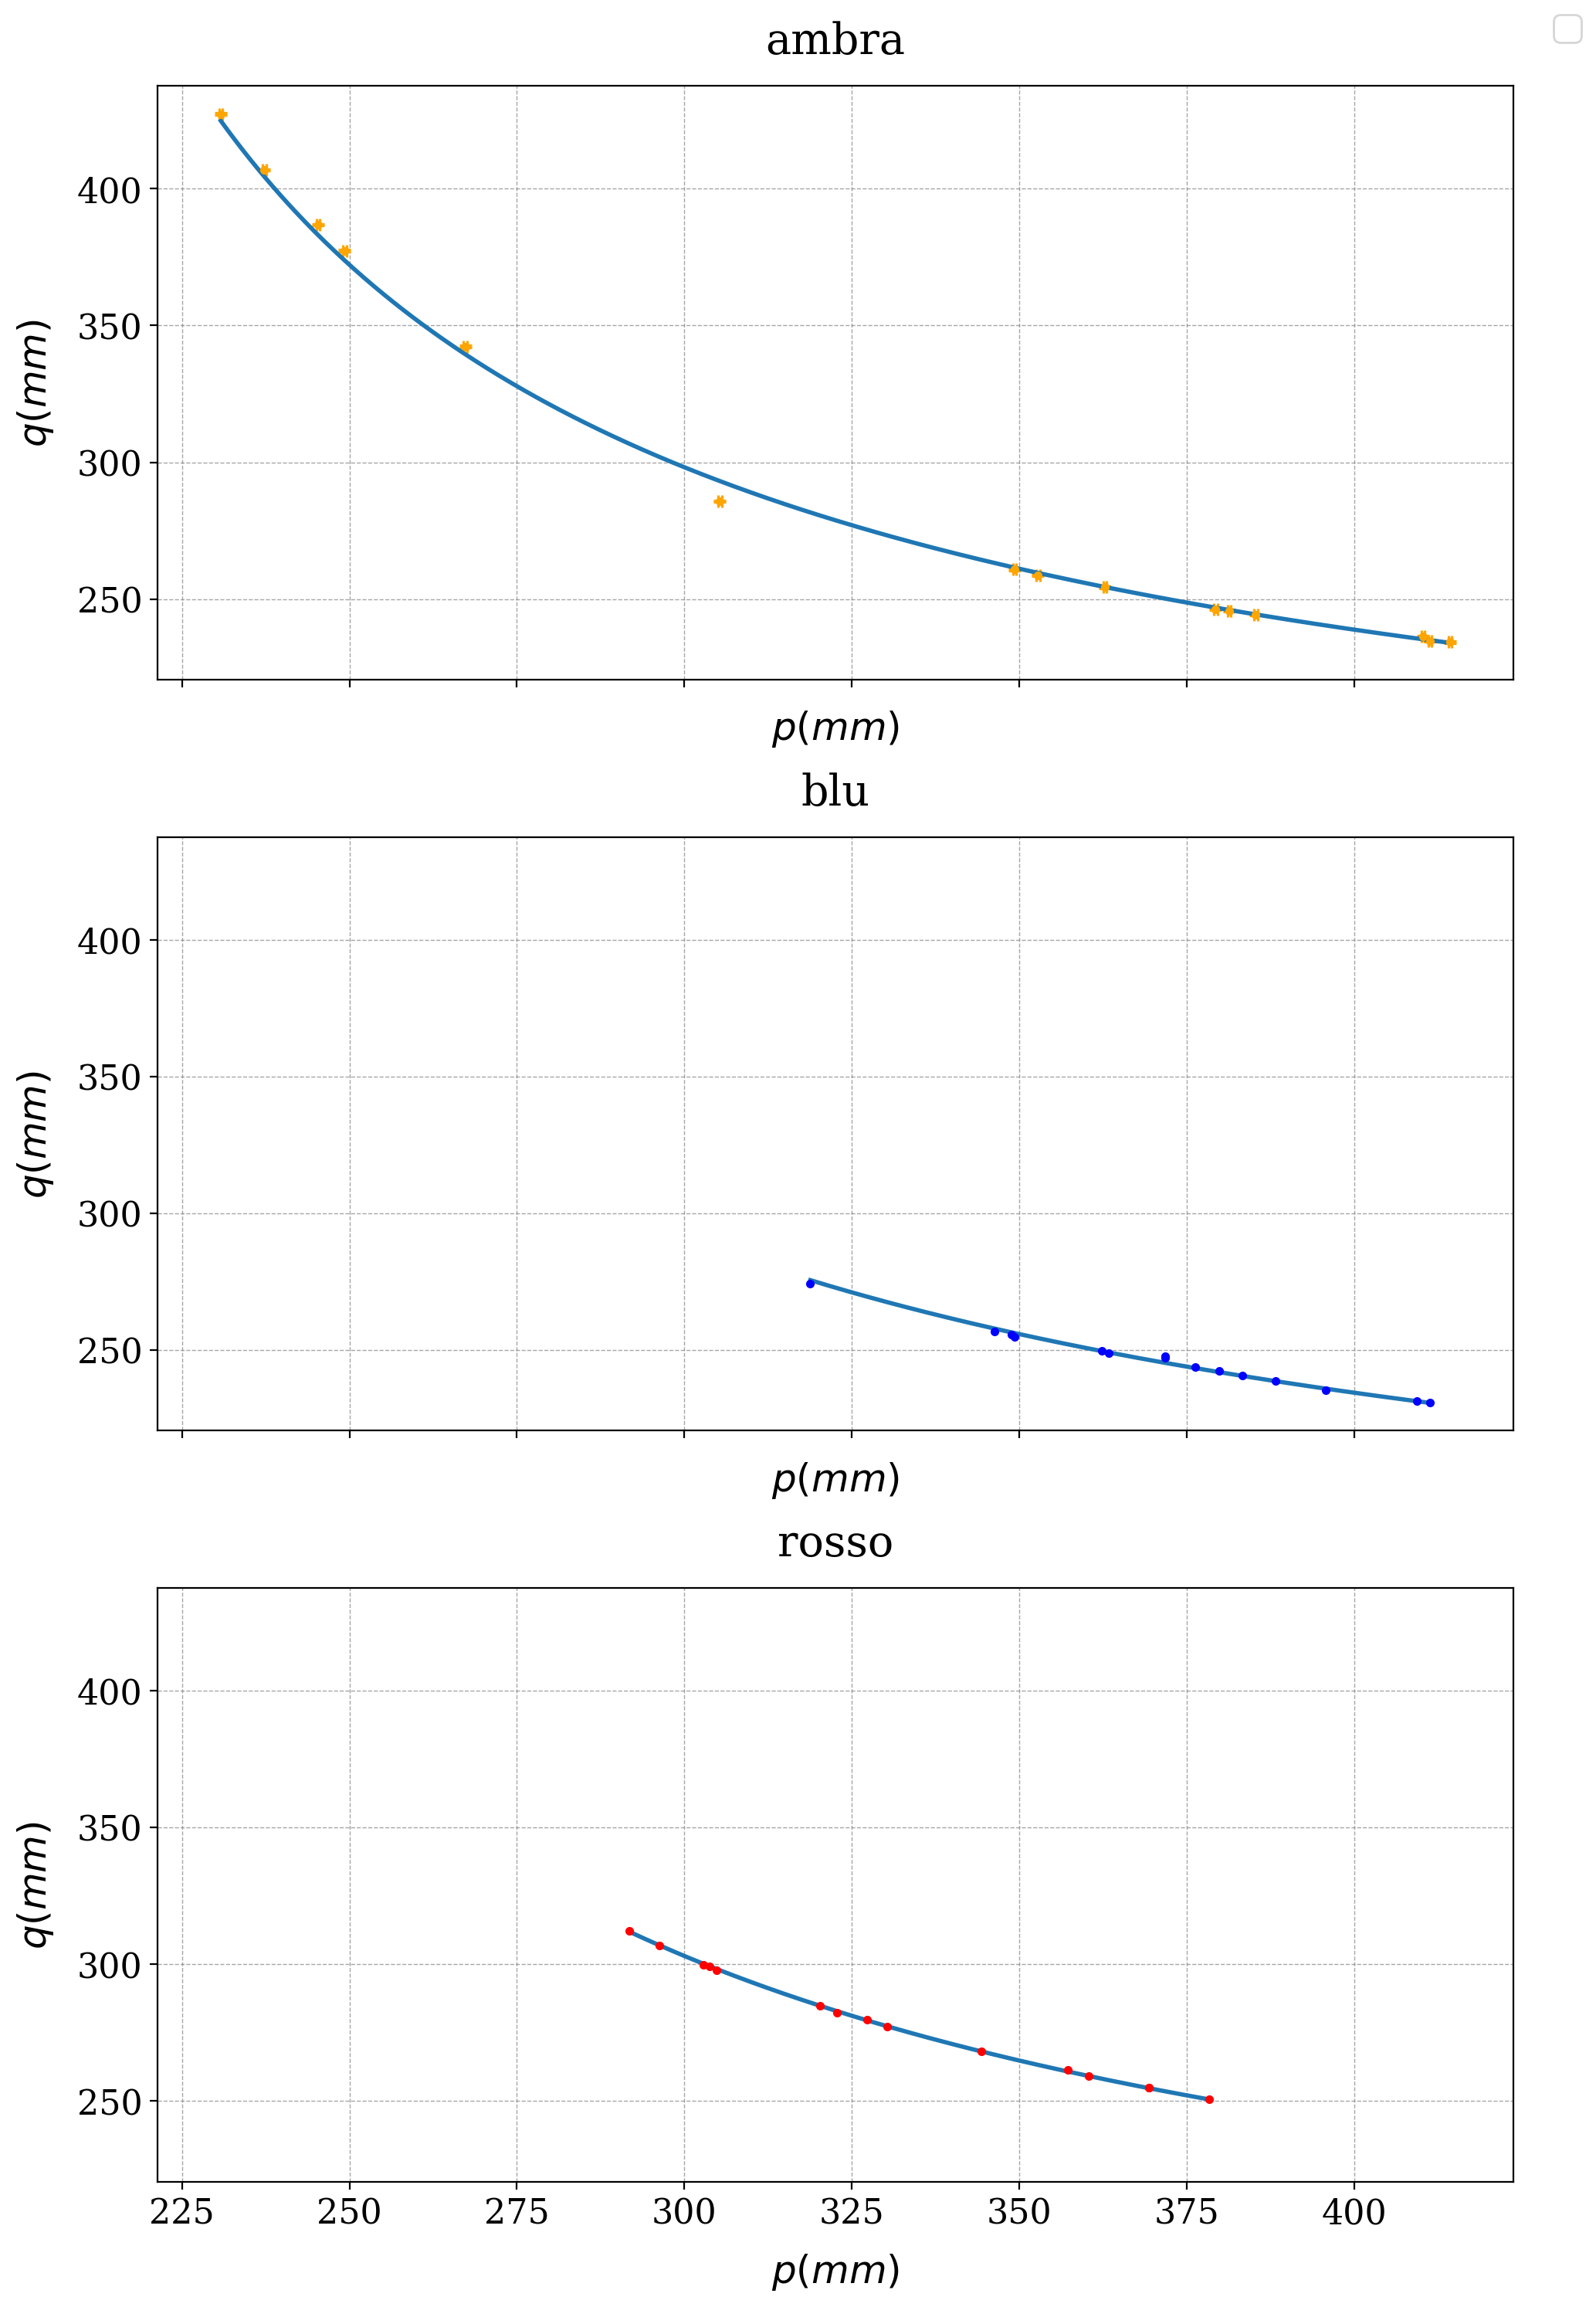

In [101]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharex=True, sharey=True)

for i, (input_file, distanza, focali) in enumerate(zip(input_files, distanze.values(), focali1.values())):

    ax = axes[i]

    titolo = nome(input_file, metodo)
    if i == 0 : colore = "orange"
    elif i == 1 : colore = "blue"
    elif i == 2 : colore = "red"

    p = distanza["p"]
    q = distanza["q"]

    ax.errorbar(p[0], q[0], xerr = p[1], yerr = q[1], color=colore, fmt=".", **gf.scaled_error_params(q[0], scale_factor=0.3))

    gf.parametri_grafico(ax, titolo, "$p(mm)$", "$q(mm)$")

    x = np.linspace(np.min(p[0]), np.max(p[0]), 500)
    y = 1 / (1/focali["f"] - 1/x)
    ax.plot(x, y)

    #stringa_f = gf.formatta_errore(focali["f"],focali["sf"])
    #gf.descrizione_legenda(ax, stringa_f, color=colore)
gf.salva_grafico(fig, "grafici_coniugati.pdf")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


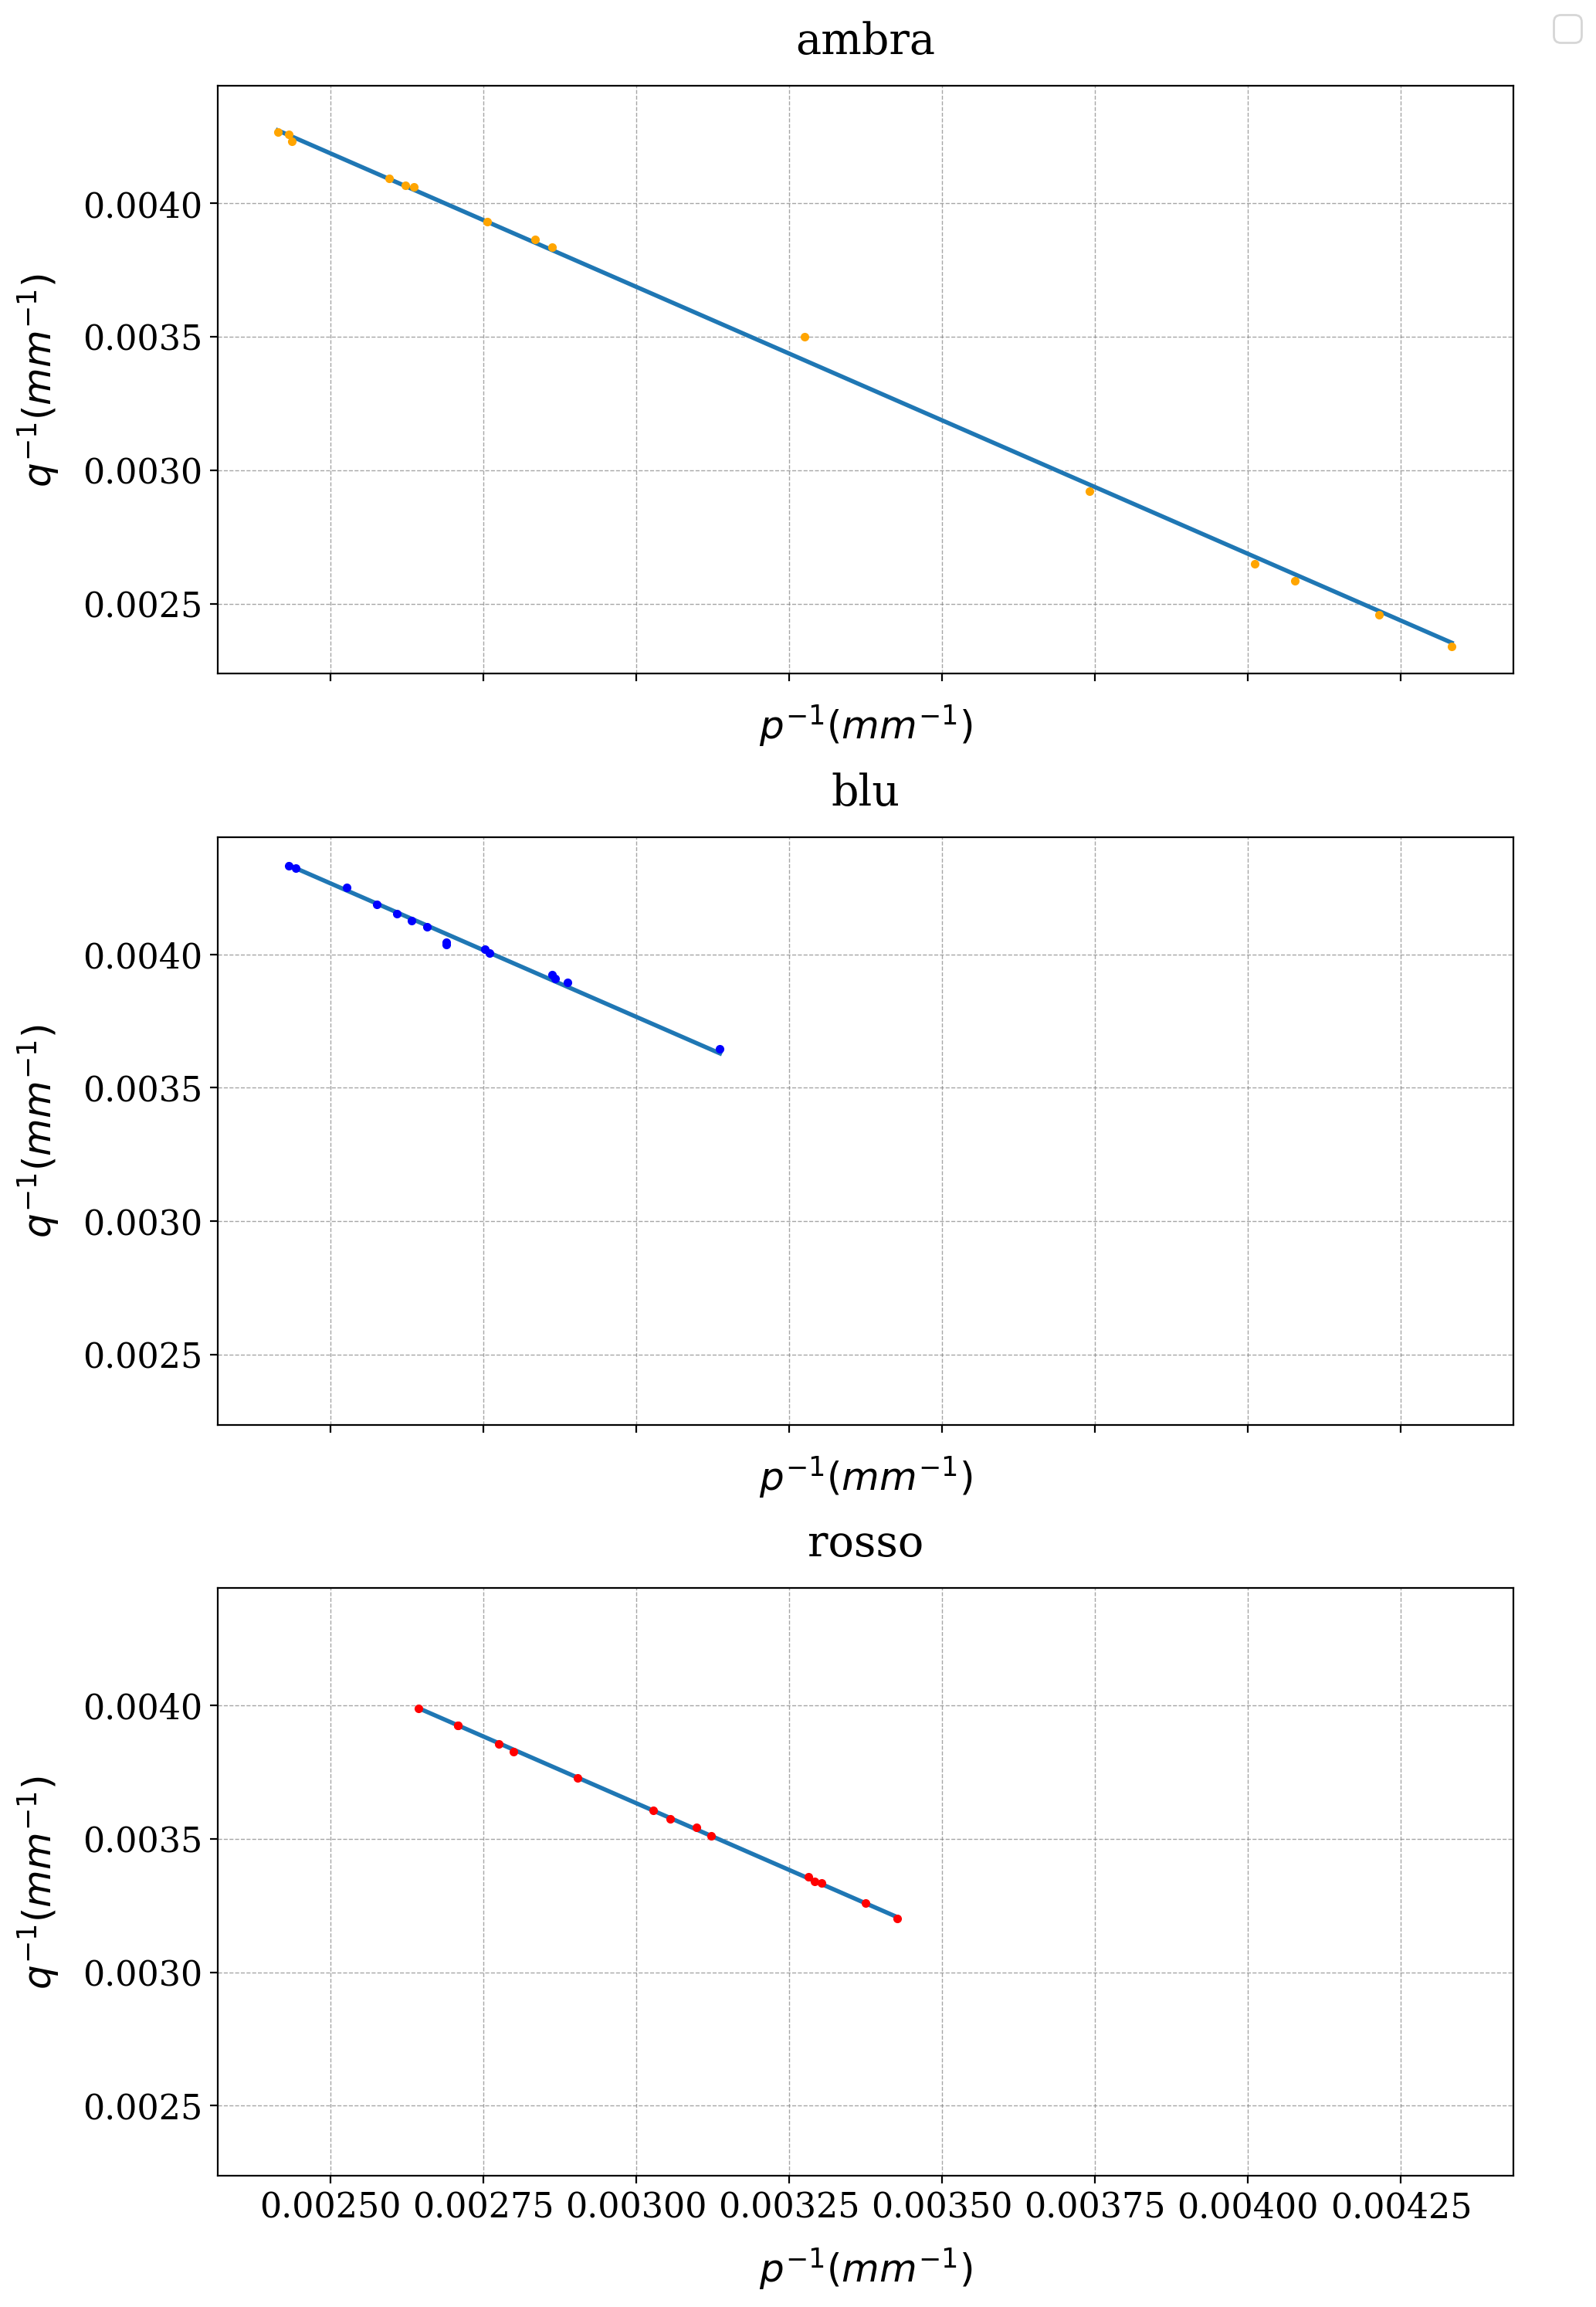

In [102]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharex=True, sharey=True)

for i, (input_file, distanza, focali) in enumerate(zip(input_files, distanze.values(), focali1.values())):

    ax = axes[i]

    titolo = nome(input_file, metodo)
    if i == 0 : colore = "orange"
    elif i == 1 : colore = "blue"
    elif i == 2 : colore = "red"

    p = distanza["p"]
    q = distanza["q"]

    ax.errorbar(1/p[0], 1/q[0], xerr = p[1] / (p[0]**2) , yerr = q[1] / (q[0]**2), color=colore, fmt=".", **gf.scaled_error_params(1/q[0], scale_factor=0.3))

    gf.parametri_grafico(ax, titolo, "$p^{-1}(mm^{-1})$", "$q^{-1}(mm^{-1})$")

    x = np.linspace(np.min(1/p[0]), np.max(1/p[0]), 500)
    y = 1/focali["f"] - x
    ax.plot(x, y)

    #stringa_f = gf.formatta_errore(focali["f"],focali["sf"])
    #gf.descrizione_legenda(ax, stringa_f, color=colore)
gf.salva_grafico(fig, "grafici_coniugati_linearizzati.pdf")

# 2. Bessel

In [78]:
metodo = "Bessel"

### 2.1 Lettura

In [79]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data2 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data2[nome(input_file, metodo)] = {
        "pl+": letti["pl+"],
        "pl-": letti["pl-"],
    }

### 2.2 Analisi

In [80]:
focali2 = {}

L = lunghezza[0] + offset_OGGETTO[0] + offset_CCD[0]
L0 = L
L_err = np.sqrt( lunghezza[1]**2 + offset_OGGETTO[1]**2 + offset_CCD[1]**2 )

for colore,dati in data2.items():

    if colore=="rosso" : L = L0 + offset_GIORNO2

    pl_piu = np.mean(np.array(dati["pl+"]))
    pl_meno = np.mean(np.array(dati["pl-"]))
    s_pl_piu = f.s_media(dati["pl+"])
    s_pl_meno = f.s_media(dati["pl-"])
    ritorno = f.propaga_incertezza("(L**2 - (pl_piu - pl_meno)**2) / (4 * L)", ["L","pl_piu","pl_meno"],
                     valori = [L, pl_piu, pl_meno],
                     incertezze = [L_err, s_pl_piu, s_pl_meno],
                     ritorno = True)
    focali2[colore] = {
        "f" : (L**2 - (pl_piu - pl_meno)**2) / (4 * L),
        "sf" : ritorno[0],
        }
L = L0

### 2.3 Confronto

In [81]:
z_scores = {}

for colore in focali1.keys():
    f1 = focali1[colore]["f"]
    sf1 = focali1[colore]["sf"]
    f2 = focali2[colore]["f"]
    sf2 = focali2[colore]["sf"]

    z = f.compatibilita(f1, sf1, f2, sf2)
    z_scores[colore] = z

In [82]:
focali = {}

for (colore,f1),f2 in zip(focali1.items(),focali2.values()):
    focali[colore] = {
        "f" : f.media_p([f1["f"],f2["f"]],[f1["sf"],f2["sf"]]),
        "sf" : f.s_media_p([f1["f"],f2["f"]],[f1["sf"],f2["sf"]]),
        }

In [83]:
f.inizializza_output(file_focali)

with open(file_focali, "a") as fl:
    fl.write("RIASSUNTO MISURE FOCALE\n")
    fl.write("========================\n\n")

    for colore in sorted(focali1.keys()):
        f1 = focali1[colore]["f"]
        sf1 = focali1[colore]["sf"]
        f2 = focali2[colore]["f"]
        sf2 = focali2[colore]["sf"]
        z = z_scores[colore]
        f0 = focali[colore]["f"]
        sf0 = focali[colore]["sf"]

        fl.write(f"Colore: {colore}\n")
        fl.write(f"  Coniugati: {gf.formatta_errore(f1, sf1, 'mm',txt=True)}\n")
        fl.write(f"  Bessel:    {gf.formatta_errore(f2, sf2, 'mm',txt=True)}\n")
        fl.write(f"  Indice di Compatibilità:   {z:.3f}\n")
        fl.write(f"  Media: {gf.formatta_errore(f0, sf0, 'mm',txt=True)}\n")
        fl.write("\n")

# 3. Aberrazione

In [84]:
metodo = "Aberrazione"

### 3.1 Lettura

In [85]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data3 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data3[nome(input_file, metodo)] = {
        "parassiale": letti["parassiale"],
        "marginale": letti["marginale"],
    }

### 3.2 Analisi

$$B = f_{parassiale} - f_{marginale}$$

$B := $ aberrazione sferica longitudinale

In [91]:
aberrazione_sferica = {}
focali3 = {}

for colore,dati in data3.items():

    f_marginale = np.mean(np.array(dati["marginale"]))
    f_parassiale = np.mean(np.array(dati["parassiale"]))
    s_f_marginale = f.s_media(dati["marginale"])
    s_f_parassiale = f.s_media(dati["parassiale"])
    
    focali3[colore] = {
        "f_marginale" : f_marginale,
        "s_f_marginale" : s_f_marginale,
        "f_parassiale" : f_parassiale,
        "s_f_parassiale" :s_f_parassiale,
    }
    
    aberrazione_sferica[colore] = {
        "aberrazione_sferica" : f_parassiale - f_marginale,
        "s_aberrazione_sferica" : f.propaga_incertezza("f_parassiale - f_marginale", ["f_parassiale", "f_marginale"],
                     valori = [f_parassiale, f_marginale],
                     incertezze = [s_f_parassiale, s_f_parassiale],
                     ritorno = True)[0],
        }

$$A = f_{rosso} - f_{blu} = \frac{f_{giallo}}{V}$$

$A := $ aberrazione cromatica longitudinale

$V := $ numero di Abbe

In [92]:
aberrazione_cromatica = [focali3["rosso"]["f_marginale"] - focali3["blu"]["f_marginale"],
                         (focali3["rosso"]["s_f_marginale"]**2 + focali3["blu"]["s_f_marginale"]**2)**0.5
                         ]

numero_abbe = [focali3["ambra"]["f_marginale"] / aberrazione_cromatica[0],
               f.propaga_incertezza(
                   "x/y",
                   ["x","y"],
                   [focali3["ambra"]["f_marginale"],aberrazione_cromatica[0]],
                   [focali3["ambra"]["s_f_marginale"],aberrazione_cromatica[1]],
                   ritorno=True
               )[0]]

In [ ]:
f.inizializza_output(file_aberrazione)

with open(file_aberrazione, "w") as fl:
    fl.write("RIASSUNTO MISURE ABERRAZIONE\n")
    fl.write("============================\n\n")

    for colore, dati in aberrazione_sferica.items():
        fl.write(f"Aberrazione sferica {colore}: {gf.formatta_errore(dati['aberrazione_sferica'],dati['s_aberrazione_sferica'],"mm",txt=True)}\n")

    fl.write("\n")
    fl.write(f"Aberrazione cromatica = {gf.formatta_errore(aberrazione_cromatica[0], aberrazione_cromatica[1], "mm", txt=True)}\n")
    fl.write(f"Numero di Abbe = {gf.formatta_errore(numero_abbe[0], numero_abbe[1], txt=True)}\n")